In [42]:
# FieldNBalance is a program that estimates the N balance and provides N fertilizer recommendations for cultivated crops.
# Author: Hamish Brown.
# Copyright (c) 2024 The New Zealand Institute for Plant and Food Research Limited

In [43]:
import os 
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

CBcolors = {
    'blue':    '#377eb8', 
    'orange':  '#ff7f00',
    'green':   '#4daf4a',
    'pink':    '#f781bf',
    'brown':   '#a65628',
    'purple':  '#984ea3',
    'gray':    '#999999',
    'red':     '#e41a1c',
    'yellow':  '#dede00',
    'black': '#000000'
} 

Path for current Tests

In [44]:
try: 
    if os.environ["GITHUB_WORKSPACE"] != None:
        root = os.environ["GITHUB_WORKSPACE"]
        inPath = os.path.join(root, "TestComponents", "TestSets", "Schedulling", "Outputs")
        outPath = os.path.join(root, "TestGraphs", "Outputs")  
        localDayFirst = False
        localDateFormat = '%m/%d/%Y %H:%M:%S'
except:
    localDayFirst = True
    localDateFormat = '%d/%m/%Y %H:%M:%S %p'
    rootfrags = os.path.abspath('Location.py').split("\\")
    root = ""
    for d in rootfrags:
        if d == "FieldNBalance":
            break
        else:
            root += d + "\\"
    inPath = os.path.join(root,"FieldNBalance","TestComponents", "TestSets", "Schedulling", "Outputs")
    outPath = os.path.join(root,"FieldNBalance","TestGraphs", "Outputs")  

Get names and results from each test

In [45]:
testFiles = []
tests = []
for file in os.listdir(inPath):
    if file.endswith('.csv'):
        testFiles.append(file)
        tests.append(file.replace(".csv",""))

Pack tests up into dataframe for graphing

In [46]:
Alltests =[]
for t in testFiles[:]:  
    testframe = pd.read_csv(os.path.join(inPath, t),index_col=0,dayfirst=localDayFirst,date_format=localDateFormat)  
    Alltests.append(testframe)   

AllData = pd.concat(Alltests,axis=1,keys=tests)
AllData.sort_index(axis=0,inplace=True)
AllData.index = pd.to_datetime(AllData.index)

Make graph

In [47]:
colors = ['purple','purple','green','green','orange','orange','blue','blue','red','red','black','yellow','yellow']
lines = ['-','--','-','--','-','--','-','--','-','--','-','-','--']

In [48]:
Stages = ['Vegetative','LateReproductive','Late']
Splits = ['1','2','3','5']
TestNames = []
for st in Stages:
    for sp in Splits:
        TestNames.append(st+'_'+sp)
TestNames.append("SetEnd_early")
TestNames.append("SetEnd_mid")
TestNames.append("SetEnd_late")
TestNames.append("SetEnd_verylate")

In [49]:
AllData.columns

MultiIndex([('EarlyReproductive_1', 'SoilMineralN'),
            ('EarlyReproductive_1',      'UptakeN'),
            ('EarlyReproductive_1',     'ResidueN'),
            ('EarlyReproductive_1',      'SoilOMN'),
            ('EarlyReproductive_1',  'FertiliserN'),
            ('EarlyReproductive_1',        'CropN'),
            ('EarlyReproductive_1',     'ProductN'),
            ('EarlyReproductive_1',        'LostN'),
            ('EarlyReproductive_1',         'RSWC'),
            ('EarlyReproductive_1',     'Drainage'),
            ...
            (       'Vegetative_5',      'SoilOMN'),
            (       'Vegetative_5',  'FertiliserN'),
            (       'Vegetative_5',        'CropN'),
            (       'Vegetative_5',     'ProductN'),
            (       'Vegetative_5',        'LostN'),
            (       'Vegetative_5',         'RSWC'),
            (       'Vegetative_5',     'Drainage'),
            (       'Vegetative_5',   'Irrigation'),
            (       'Vegetativ

In [50]:
TestNames

['Vegetative_1',
 'Vegetative_2',
 'Vegetative_3',
 'Vegetative_5',
 'LateReproductive_1',
 'LateReproductive_2',
 'LateReproductive_3',
 'LateReproductive_5',
 'Late_1',
 'Late_2',
 'Late_3',
 'Late_5',
 'SetEnd_early',
 'SetEnd_mid',
 'SetEnd_late',
 'SetEnd_verylate']

C:\Users\Cflhxb\AppData\Local\Temp\ipykernel_10936\336625129.py:32: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  Graph.tight_layout(pad=1.5)


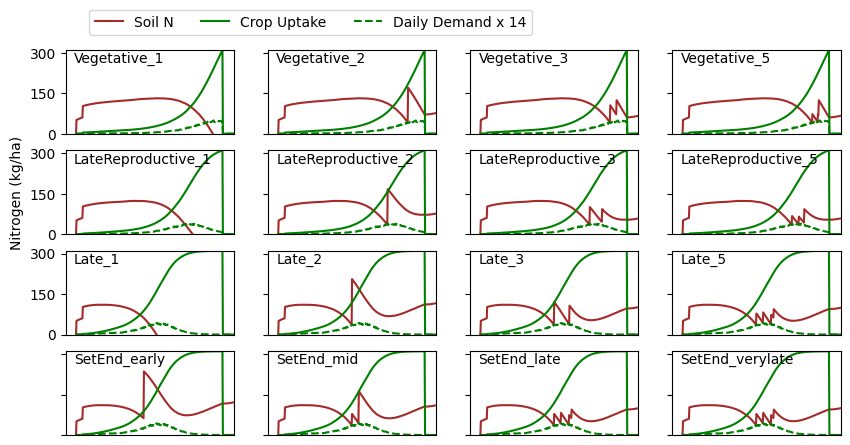

In [51]:
Graph = plt.figure(figsize=(10,5))

pos = 1
for t in TestNames:
    ax = Graph.add_subplot(4,4,pos)
    plt.plot(AllData.loc[:,(t,'SoilMineralN')],color = 'brown',label = 'Soil N')
    #plt.plot(AllData.loc[:,(t,'FertiliserN')],label = 'Fertiliser')
    #plt.plot(AllData.loc[:,(t,'CropN')],label = 'CropN')
    plt.plot(AllData.loc[:,(t,'NDemand')],color = 'green',label = 'Crop Uptake')
    #plt.plot(AllData.loc[:,(t,'LostN')],label = 'LostN')
    #plt.plot(AllData.loc[:,(t,'SoilOMN')].cumsum(),label = 'SoilOMN')
    #plt.plot(AllData.loc[:,(t,'ResidueN')].cumsum(),label = 'ResidueN')
    plt.plot(AllData.loc[:,(t,'UptakeN')]*14, '--',color = 'green',label = 'Daily Demand x 14')
    
    plt.text(0.05,0.85,t,fontsize = 10,transform=ax.transAxes)
    if pos == 1:
        plt.legend(ncols=3,loc='lower left', bbox_to_anchor=(0.1, 1.1))
        
    if pos in [1,5,9]:
        ax.set_yticks(ticks = [0,150,300],labels = [0,150,300])
        if pos ==5:
            plt.ylabel('Nitrogen (kg/ha)')
    else:
        ax.set_yticks(ticks = [0,150,300],labels = ["","",""])
    
    ax.set_xticks(ticks = [])
                                   
    ax.set_xlim(np.datetime64("2023-03-01"), np.datetime64("2024-04-01"))
    pos +=1
    plt.ylim(0,310)    
# plt.text(0.05,0.95,"Crop Cover with different Establish and Harvest Stages",fontsize = 16,transform=ax.transAxes)
Graph.tight_layout(pad=1.5)

plt.savefig(os.path.join(outPath,'8-Schedulling_SoilN.png'))